# Final results analysis

This notebook reproduces the tables and figures used in the thesis from the archived experiment outputs in `results/`.

The analysis covers the MNIST screening stage (`B=100`), the definitive CIFAR-10 and Tiny ImageNet study (`B=1000` for GA/RS), the SSRS and global k-center greedy (KCG) baselines, and the 100% base training reference. Training is **not** rerun here; the notebook only reads saved experiment artifacts.


In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats


# Resolve the repository root whether Jupyter was started from the project
# root or from the notebooks directory.
candidate_roots = [Path.cwd(), Path.cwd().parent]
REPO_ROOT = next(
    (path for path in candidate_roots if (path / "results").exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the repository 'results' directory."
    )

RESULTS_DIR = REPO_ROOT / "results"
OUTPUT_DIR = REPO_ROOT / "analysis_outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

SEEDS = [42, 123, 456, 789, 1024]
RETENTIONS = [10, 25, 50, 75, 90]

DATASET_NAMES = {
    "CIFAR10": "CIFAR-10",
    "TINYIMAGENET": "Tiny ImageNet",
}

PRELIMINARY_MODEL_NAMES = {
    "alexnet": "AlexNet",
    "resnext": "ResNeXt-50",
    "efficientnetv2": "EfficientNetV2-S",
    "swintransformer": "Swin-T",
}

PRELIMINARY_ALGORITHM_NAMES = {
    "RS": "RS",
    "LS": "LNS",
    "GEN": "GA",
    "MEM": "MA",
}

# Archived result files use the raw algorithm code "SRS"; the thesis
# terminology is "SSRS" (Single Stratified Random Sample).
MAIN_METHOD_NAMES = {
    "GEN": "GA",
    "RS": "RS",
    "SRS": "SSRS",
    "KCG": "KCG",
}

print(f"Results directory: {RESULTS_DIR.resolve()}")
print(f"Output directory:  {OUTPUT_DIR.resolve()}")

Results directory: C:\Users\Juan Manuel\Desktop\tfm\results
Output directory:  C:\Users\Juan Manuel\Desktop\tfm\analysis_outputs


In [2]:
def load_top_level_csvs(directory_pattern, filename):
    """Load one top-level CSV from every experiment directory matching a pattern."""
    frames = []

    for experiment_dir in sorted(RESULTS_DIR.glob(directory_pattern)):
        csv_path = experiment_dir / filename

        if not csv_path.exists():
            continue

        frame = pd.read_csv(csv_path)
        frame["_experiment_dir"] = experiment_dir.name
        frames.append(frame)

    if not frames:
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)


def holm_adjust(p_values):
    """Apply Holm's step-down correction to a sequence of p-values."""
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)

    running_maximum = 0.0
    number_of_tests = len(p_values)

    for position, original_index in enumerate(order):
        corrected = (
            number_of_tests - position
        ) * p_values[original_index]

        running_maximum = max(running_maximum, corrected)
        adjusted[original_index] = min(running_maximum, 1.0)

    return adjusted


def exact_wilcoxon(x, y):
    """Run a two-sided paired Wilcoxon test with a safe exact/automatic fallback."""
    differences = np.asarray(x, dtype=float) - np.asarray(y, dtype=float)

    # SciPy cannot always use the exact distribution when zero differences occur.
    method = "exact" if np.all(differences != 0) else "auto"

    return stats.wilcoxon(
        x,
        y,
        alternative="two-sided",
        zero_method="wilcox",
        method=method,
    )


def format_mean_std(mean_value, std_value, scale=100.0, decimals=2):
    """Format a mean and sample standard deviation for paper-ready tables."""
    return (
        f"{mean_value * scale:.{decimals}f} "
        f"± {std_value * scale:.{decimals}f}"
    )


def save_figure(filename):
    """Save the current Matplotlib figure as PDF and high-resolution PNG."""
    pdf_path = FIGURES_DIR / f"{filename}.pdf"
    png_path = FIGURES_DIR / f"{filename}.png"

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")

    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")


def assert_expected_values(series, expected, label):
    """Validate that a categorical column contains exactly the expected values."""
    observed = set(series.dropna().unique())
    expected = set(expected)

    if observed != expected:
        raise AssertionError(
            f"{label}: expected {sorted(expected)}, observed {sorted(observed)}"
        )

## 1. Preliminary screening: MNIST

The preliminary analysis uses the 400 MNIST searches only: four frozen representations, four search methods, five retention levels, and five seeds.


In [3]:
preliminary_df = load_top_level_csvs(
    "preliminary/mnist/prelim_features_mnist_*",
    "search_summary.csv",
)

preliminary_df = preliminary_df[
    (preliminary_df["dataset"] == "MNIST")
    & (preliminary_df["status"] == "completed")
    & (preliminary_df["max_evaluations"] == 100)
].copy()

preliminary_df["retention"] = (
    preliminary_df["keep_percentage"] * 100
).round().astype(int)

preliminary_df["model_name"] = preliminary_df["model"].map(
    PRELIMINARY_MODEL_NAMES
)
preliminary_df["algorithm_name"] = preliminary_df["algorithm"].map(
    PRELIMINARY_ALGORITHM_NAMES
)
preliminary_df["method"] = (
    preliminary_df["model_name"]
    + " + "
    + preliminary_df["algorithm_name"]
)

# Integrity checks for the complete 4 × 4 × 5 × 5 preliminary matrix.
assert len(preliminary_df) == 400
assert preliminary_df["model"].nunique() == 4
assert preliminary_df["algorithm"].nunique() == 4
assert_expected_values(preliminary_df["retention"], RETENTIONS, "Retentions")
assert_expected_values(preliminary_df["search_seed"], SEEDS, "Seeds")

print(f"Loaded preliminary runs: {len(preliminary_df)}/400")
display(
    preliminary_df[
        [
            "model_name",
            "algorithm_name",
            "retention",
            "search_seed",
            "best_fitness",
            "search_duration_seconds",
        ]
    ].head()
)

Loaded preliminary runs: 400/400


,model_name,algorithm_name,retention,search_seed,best_fitness,search_duration_seconds
0,AlexNet,GA,10,1024,0.956667,852.531962
1,AlexNet,GA,10,123,0.956167,851.395833
2,AlexNet,GA,10,42,0.955583,853.713243
3,AlexNet,GA,10,456,0.955417,852.664044
4,AlexNet,GA,10,789,0.956917,851.942366


In [4]:
# Preliminary global table

# The paper uses the search seed as the independent replication unit.
# Therefore, ranking is performed after averaging the five retention levels
# within each method and seed.
seed_aggregates = (
    preliminary_df
    .groupby(["search_seed", "method"], as_index=False)
    .agg(seed_mean_fitness=("best_fitness", "mean"))
)

seed_aggregates["seed_rank"] = (
    seed_aggregates
    .groupby("search_seed")["seed_mean_fitness"]
    .rank(ascending=False, method="average")
)

seed_aggregates["seed_win"] = seed_aggregates["seed_rank"] == 1

preliminary_global = (
    preliminary_df
    .groupby("method")
    .agg(
        mean_accuracy=("best_fitness", "mean"),
        std_accuracy=("best_fitness", "std"),
        mean_time_seconds=("search_duration_seconds", "mean"),
        runs=("best_fitness", "size"),
    )
    .reset_index()
)

rank_summary = (
    seed_aggregates
    .groupby("method")
    .agg(
        mean_rank=("seed_rank", "mean"),
        seed_wins=("seed_win", "sum"),
    )
    .reset_index()
)

preliminary_global = preliminary_global.merge(
    rank_summary,
    on="method",
    how="left",
)

preliminary_global["mean_accuracy_pct"] = (
    preliminary_global["mean_accuracy"] * 100
)
preliminary_global["std_accuracy_pp"] = (
    preliminary_global["std_accuracy"] * 100
)
preliminary_global["mean_time_minutes"] = (
    preliminary_global["mean_time_seconds"] / 60
)

preliminary_global = preliminary_global.sort_values(
    ["mean_accuracy_pct", "mean_rank"],
    ascending=[False, True],
).reset_index(drop=True)

display(
    preliminary_global[
        [
            "method",
            "mean_accuracy_pct",
            "std_accuracy_pp",
            "mean_rank",
            "seed_wins",
            "mean_time_minutes",
            "runs",
        ]
    ].round(4)
)

preliminary_global.to_csv(
    TABLES_DIR / "mnist_preliminary_global.csv",
    index=False,
)

,method,mean_accuracy_pct,std_accuracy_pp,mean_rank,seed_wins,mean_time_minutes,runs
0,AlexNet + GA,96.9757,0.7756,1.6,3,37.7683,25
1,AlexNet + RS,96.9437,0.8327,2.7,0,37.6820,25
2,AlexNet + MA,96.9437,0.8003,3.1,0,36.2726,25
3,ResNeXt-50 + GA,96.9177,0.8368,3.4,2,34.6510,25
4,AlexNet + LNS,96.8907,0.8744,4.8,0,37.5931,25
5,ResNeXt-50 + MA,96.8820,0.8990,5.6,0,35.8828,25
6,ResNeXt-50 + RS,96.8427,0.9253,6.8,0,36.3026,25
7,ResNeXt-50 + LNS,96.7683,0.9913,8.0,0,35.7628,25
8,Swin-T + MA,96.6017,0.8875,10.3,0,26.0063,25
9,Swin-T + GA,96.5980,0.8785,10.3,0,26.5407,25


,retention,method,mean_accuracy_pct,std_accuracy_pp
0,10,AlexNet + GA,95.6150,0.0655
16,25,AlexNet + GA,96.7217,0.0883
40,50,ResNeXt-50 + GA,97.3067,0.0587
50,75,AlexNet + MA,97.6000,0.0300
67,90,AlexNet + RS,97.7067,0.0181


Saved: c:\Users\Juan Manuel\Desktop\tfm\analysis_outputs\figures\mnist_alexnet_algorithms.pdf
Saved: c:\Users\Juan Manuel\Desktop\tfm\analysis_outputs\figures\mnist_alexnet_algorithms.png


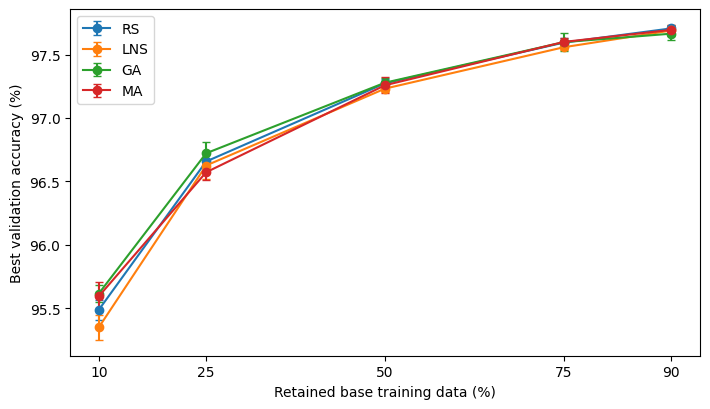

In [5]:
# Best preliminary configuration at each retention level

preliminary_by_retention = (
    preliminary_df
    .groupby(["retention", "method"])
    .agg(
        mean_accuracy=("best_fitness", "mean"),
        std_accuracy=("best_fitness", "std"),
    )
    .reset_index()
)

preliminary_by_retention["mean_accuracy_pct"] = (
    preliminary_by_retention["mean_accuracy"] * 100
)
preliminary_by_retention["std_accuracy_pp"] = (
    preliminary_by_retention["std_accuracy"] * 100
)

best_preliminary_by_retention = (
    preliminary_by_retention
    .sort_values(
        ["retention", "mean_accuracy_pct"],
        ascending=[True, False],
    )
    .groupby("retention", as_index=False)
    .head(1)
)

display(
    best_preliminary_by_retention[
        [
            "retention",
            "method",
            "mean_accuracy_pct",
            "std_accuracy_pp",
        ]
    ].round(4)
)

best_preliminary_by_retention.to_csv(
    TABLES_DIR / "mnist_best_by_retention.csv",
    index=False,
)


# Figure: AlexNet preliminary comparison

alexnet_preliminary = (
    preliminary_df[preliminary_df["model"] == "alexnet"]
    .groupby(["algorithm_name", "retention"])
    .agg(
        mean_accuracy=("best_fitness", "mean"),
        std_accuracy=("best_fitness", "std"),
    )
    .reset_index()
)

plt.figure(figsize=(7.2, 4.2))

for method in ["RS", "LNS", "GA", "MA"]:
    method_data = alexnet_preliminary[
        alexnet_preliminary["algorithm_name"] == method
    ].sort_values("retention")

    plt.errorbar(
        method_data["retention"],
        method_data["mean_accuracy"] * 100,
        yerr=method_data["std_accuracy"] * 100,
        marker="o",
        capsize=3,
        label=method,
    )

plt.xlabel("Retained base training data (%)")
plt.ylabel("Best validation accuracy (%)")
plt.xticks(RETENTIONS)
plt.legend()
plt.tight_layout()

save_figure("mnist_alexnet_algorithms")
plt.show()

In [6]:
# Preliminary statistical diagnostics

preliminary_pivot = seed_aggregates.pivot(
    index="search_seed",
    columns="method",
    values="seed_mean_fitness",
)

friedman_preliminary = stats.friedmanchisquare(
    *[
        preliminary_pivot[column]
        for column in preliminary_pivot.columns
    ]
)

print(
    f"Preliminary Friedman statistic: "
    f"{friedman_preliminary.statistic:.6f}"
)
print(
    f"Preliminary Friedman p-value: "
    f"{friedman_preliminary.pvalue:.6e}"
)

selected_method = "AlexNet + GA"

posthoc_records = []

for competitor in preliminary_pivot.columns:
    if competitor == selected_method:
        continue

    result = exact_wilcoxon(
        preliminary_pivot[selected_method],
        preliminary_pivot[competitor],
    )

    differences_pp = (
        preliminary_pivot[selected_method]
        - preliminary_pivot[competitor]
    ) * 100

    posthoc_records.append(
        {
            "selected_method": selected_method,
            "competitor": competitor,
            "mean_difference_pp": differences_pp.mean(),
            "wilcoxon_statistic": result.statistic,
            "raw_p_value": result.pvalue,
        }
    )

preliminary_posthoc = pd.DataFrame(posthoc_records)
preliminary_posthoc["holm_p_value"] = holm_adjust(
    preliminary_posthoc["raw_p_value"]
)

display(
    preliminary_posthoc
    .sort_values("holm_p_value")
    .round(6)
)

preliminary_posthoc.to_csv(
    TABLES_DIR / "mnist_preliminary_posthoc.csv",
    index=False,
)

print(
    "Theoretical minimum two-sided Wilcoxon p-value with five "
    "non-zero paired differences: 0.0625"
)
print(
    "Theoretical minimum first Holm-adjusted value for 15 comparisons: "
    "15 × 0.0625 = 0.9375"
)

Preliminary Friedman statistic: 71.009417
Preliminary Friedman p-value: 2.950865e-09


,selected_method,competitor,mean_difference_pp,wilcoxon_statistic,raw_p_value,holm_p_value
0,AlexNet + GA,AlexNet + LNS,0.085000,0.0,0.0625,0.9375
1,AlexNet + GA,AlexNet + MA,0.032000,1.0,0.1250,0.9375
2,AlexNet + GA,AlexNet + RS,0.032000,0.0,0.0625,0.9375
3,AlexNet + GA,EfficientNetV2-S + GA,0.379667,0.0,0.0625,0.9375
4,AlexNet + GA,EfficientNetV2-S + LNS,0.490333,0.0,0.0625,0.9375
5,AlexNet + GA,EfficientNetV2-S + MA,0.409000,0.0,0.0625,0.9375
6,AlexNet + GA,EfficientNetV2-S + RS,0.427667,0.0,0.0625,0.9375
7,AlexNet + GA,ResNeXt-50 + GA,0.058000,3.0,0.3125,0.9375
8,AlexNet + GA,ResNeXt-50 + LNS,0.207333,0.0,0.0625,0.9375
9,AlexNet + GA,ResNeXt-50 + MA,0.093667,0.0,0.0625,0.9375


Theoretical minimum two-sided Wilcoxon p-value with five non-zero paired differences: 0.0625
Theoretical minimum first Holm-adjusted value for 15 comparisons: 15 × 0.0625 = 0.9375


## 2. Definitive main study

The main analysis combines GA and RS (`B=1000`), SSRS, global k-center greedy (KCG), and the 100% base training baseline on CIFAR-10 and Tiny ImageNet.


In [7]:
# Definitive main-stage loading

main_search_df = load_top_level_csvs(
    "main/guided_b1000/main_b1000_*",
    "search_summary.csv",
)
main_test_df = load_top_level_csvs(
    "main/guided_b1000/main_b1000_*",
    "test_summary.csv",
)

srs_search_df = load_top_level_csvs(
    "main/srs/main_srs_*",
    "search_summary.csv",
)
srs_test_df = load_top_level_csvs(
    "main/srs/main_srs_*",
    "test_summary.csv",
)

kcg_search_df = load_top_level_csvs(
    "main/kcg/main_global_kcg_*",
    "search_summary.csv",
)
kcg_test_df = load_top_level_csvs(
    "main/kcg/main_global_kcg_*",
    "test_summary.csv",
)

full_test_df = load_top_level_csvs(
    "main/full_data/main_full100_zeus_*",
    "test_summary.csv",
)

# Keep only the actual 100% base training records. The carrier experiments
# also contain auxiliary SSRS records that must not be counted again.
full_test_df = full_test_df[
    full_test_df["record_type"] == "baseline_100pct"
].copy()

# Keep only definitive, completed selected-mask records.
main_test_df = main_test_df[
    (main_test_df["record_type"] == "selected_mask")
    & (main_test_df["status"] == "completed")
].copy()

srs_test_df = srs_test_df[
    (srs_test_df["record_type"] == "selected_mask")
    & (srs_test_df["status"] == "completed")
].copy()

kcg_test_df = kcg_test_df[
    (kcg_test_df["record_type"] == "selected_mask")
    & (kcg_test_df["status"] == "completed")
].copy()

# Main GA/RS searches must use exactly B=1000.
main_search_df = main_search_df[
    (main_search_df["status"] == "completed")
    & (main_search_df["max_evaluations"] == 1000)
    & (main_search_df["evaluations_done"] == 1000)
].copy()

# SSRS and KCG are selection baselines without validation fitness evaluations.
srs_search_df = srs_search_df[
    (srs_search_df["status"] == "completed")
    & (srs_search_df["evaluations_done"] == 0)
].copy()

kcg_search_df = kcg_search_df[
    (kcg_search_df["status"] == "completed")
    & (kcg_search_df["evaluations_done"] == 0)
].copy()

# Integrity checks.
assert len(main_search_df) == 100
assert len(main_test_df) == 100
assert len(srs_search_df) == 50
assert len(srs_test_df) == 50
assert len(kcg_search_df) == 50
assert len(kcg_test_df) == 50
assert len(full_test_df) == 10

assert set(main_search_df["algorithm"]) == {"GEN", "RS"}
assert set(srs_search_df["selection_strategy"]) == {
    "single_class_stratified_random_sample"
}
assert set(kcg_search_df["selection_strategy"]) == {
    "global_k_center_greedy"
}

print(f"GA/RS B=1000 search runs: {len(main_search_df)}/100")
print(f"GA/RS final tests:        {len(main_test_df)}/100")
print(f"SSRS selections/tests:    {len(srs_test_df)}/50")
print(f"KCG selections/tests:     {len(kcg_test_df)}/50")
print(f"100% base training baselines: {len(full_test_df)}/10")

GA/RS B=1000 search runs: 100/100
GA/RS final tests:        100/100
SSRS selections/tests:    50/50
KCG selections/tests:     50/50
100% base training baselines: 10/10


In [8]:
# Unified main-stage test table

selected_test_df = pd.concat(
    [main_test_df, srs_test_df, kcg_test_df],
    ignore_index=True,
)

selected_test_df["method"] = selected_test_df["algorithm"].map(
    MAIN_METHOD_NAMES
)
selected_test_df["retention"] = (
    selected_test_df["keep_percentage"] * 100
).round().astype(int)
selected_test_df["dataset_name"] = selected_test_df["dataset"].map(
    DATASET_NAMES
)

# Validate the complete 2 datasets × 4 methods × 5 retentions × 5 seeds matrix.
expected_blocks = (
    selected_test_df
    .groupby(["dataset", "method", "retention"])
    .size()
)

if not (expected_blocks == 5).all():
    raise AssertionError(
        "At least one dataset-method-retention configuration does not "
        "contain exactly five seeds."
    )

full_test_df["method"] = "100% base training"
full_test_df["retention"] = 100
full_test_df["dataset_name"] = full_test_df["dataset"].map(
    DATASET_NAMES
)

main_performance = (
    selected_test_df
    .groupby(["dataset_name", "retention", "method"])
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        final_time_mean=("test_duration_seconds", "mean"),
        final_time_std=("test_duration_seconds", "std"),
        seeds=("accuracy", "size"),
    )
    .reset_index()
)

full_performance = (
    full_test_df
    .groupby(["dataset_name", "retention", "method"])
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        final_time_mean=("test_duration_seconds", "mean"),
        final_time_std=("test_duration_seconds", "std"),
        seeds=("accuracy", "size"),
    )
    .reset_index()
)

all_performance = pd.concat(
    [main_performance, full_performance],
    ignore_index=True,
).sort_values(
    ["dataset_name", "retention", "method"]
)

paper_performance = all_performance[
    ["dataset_name", "retention", "method", "seeds"]
].copy()

for metric in ["accuracy", "precision", "recall", "f1"]:
    paper_performance[metric.capitalize()] = all_performance.apply(
        lambda row: format_mean_std(
            row[f"{metric}_mean"],
            row[f"{metric}_std"],
        ),
        axis=1,
    )

for dataset_name in DATASET_NAMES.values():
    print(f"\n{dataset_name}")
    display(
        paper_performance[
            paper_performance["dataset_name"] == dataset_name
        ][
            [
                "retention",
                "method",
                "Accuracy",
                "Precision",
                "Recall",
                "F1",
                "seeds",
            ]
        ]
    )

all_performance.to_csv(
    TABLES_DIR / "main_performance_numeric.csv",
    index=False,
)
paper_performance.to_csv(
    TABLES_DIR / "main_performance_paper.csv",
    index=False,
)


CIFAR-10


,retention,method,Accuracy,Precision,Recall,F1,seeds
0,10,GA,77.48 ± 0.32,77.71 ± 0.40,77.48 ± 0.32,77.46 ± 0.35,5
1,10,KCG,76.88 ± 0.45,77.04 ± 0.28,76.88 ± 0.45,76.82 ± 0.46,5
2,10,RS,76.97 ± 0.58,77.63 ± 0.37,76.97 ± 0.58,77.07 ± 0.52,5
3,10,SSRS,76.72 ± 0.22,77.04 ± 0.36,76.72 ± 0.22,76.65 ± 0.28,5
4,25,GA,79.18 ± 0.25,79.47 ± 0.31,79.18 ± 0.25,79.16 ± 0.22,5
5,25,KCG,78.36 ± 0.13,78.74 ± 0.20,78.36 ± 0.13,78.33 ± 0.18,5
6,25,RS,78.92 ± 0.48,79.24 ± 0.42,78.92 ± 0.48,78.86 ± 0.46,5
7,25,SSRS,79.00 ± 0.31,79.39 ± 0.30,79.00 ± 0.31,78.95 ± 0.28,5
8,50,GA,79.97 ± 0.45,80.18 ± 0.51,79.97 ± 0.45,79.86 ± 0.51,5
9,50,KCG,79.61 ± 0.59,80.11 ± 0.42,79.61 ± 0.59,79.56 ± 0.64,5



Tiny ImageNet


,retention,method,Accuracy,Precision,Recall,F1,seeds
20,10,GA,41.30 ± 0.37,42.31 ± 0.52,41.30 ± 0.37,40.97 ± 0.45,5
21,10,KCG,39.89 ± 0.36,42.15 ± 0.26,39.89 ± 0.36,39.11 ± 0.18,5
22,10,RS,41.32 ± 0.50,42.21 ± 0.60,41.32 ± 0.50,40.90 ± 0.59,5
23,10,SSRS,41.47 ± 0.11,42.07 ± 0.31,41.47 ± 0.11,41.13 ± 0.18,5
24,25,GA,41.75 ± 0.52,47.44 ± 0.47,41.75 ± 0.52,41.27 ± 0.67,5
25,25,KCG,45.72 ± 0.62,47.06 ± 0.31,45.72 ± 0.62,45.51 ± 0.64,5
26,25,RS,40.73 ± 0.90,47.51 ± 0.40,40.73 ± 0.90,40.29 ± 0.88,5
27,25,SSRS,40.96 ± 0.37,46.78 ± 0.62,40.96 ± 0.37,40.47 ± 0.66,5
28,50,GA,43.40 ± 0.63,49.63 ± 0.49,43.40 ± 0.63,43.14 ± 0.68,5
29,50,KCG,42.72 ± 0.66,49.61 ± 0.45,42.72 ± 0.66,42.46 ± 0.61,5


Saved: c:\Users\Juan Manuel\Desktop\tfm\analysis_outputs\figures\cifar10_test_accuracy_all_methods.pdf
Saved: c:\Users\Juan Manuel\Desktop\tfm\analysis_outputs\figures\cifar10_test_accuracy_all_methods.png


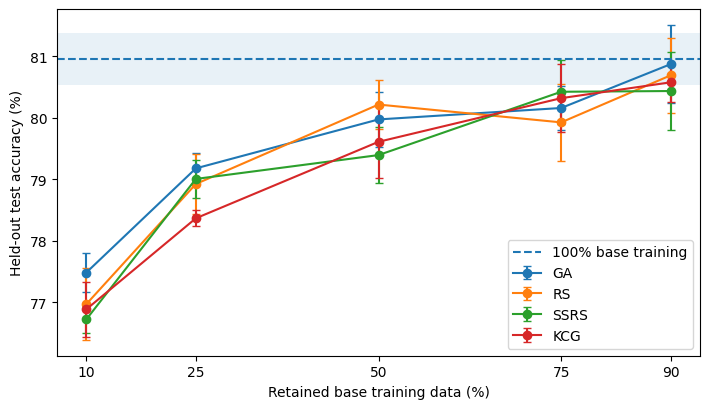

Saved: c:\Users\Juan Manuel\Desktop\tfm\analysis_outputs\figures\tinyimagenet_test_accuracy_all_methods.pdf
Saved: c:\Users\Juan Manuel\Desktop\tfm\analysis_outputs\figures\tinyimagenet_test_accuracy_all_methods.png


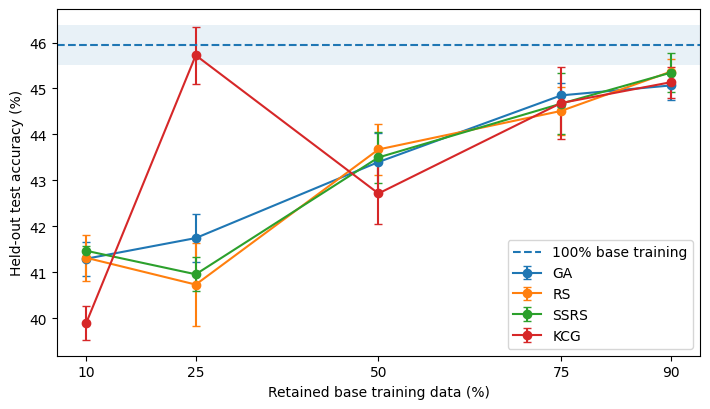

In [9]:
# Main figure: held-out test accuracy vs retained data

for dataset_code, dataset_name in DATASET_NAMES.items():
    dataset_results = main_performance[
        main_performance["dataset_name"] == dataset_name
    ]

    baseline = full_performance[
        full_performance["dataset_name"] == dataset_name
    ].iloc[0]

    plt.figure(figsize=(7.2, 4.2))

    for method in ["GA", "RS", "SSRS", "KCG"]:
        method_data = dataset_results[
            dataset_results["method"] == method
        ].sort_values("retention")

        plt.errorbar(
            method_data["retention"],
            method_data["accuracy_mean"] * 100,
            yerr=method_data["accuracy_std"] * 100,
            marker="o",
            capsize=3,
            label=method,
        )

    baseline_mean = baseline["accuracy_mean"] * 100
    baseline_std = baseline["accuracy_std"] * 100

    plt.axhline(
        baseline_mean,
        linestyle="--",
        label="100% base training",
    )
    plt.axhspan(
        baseline_mean - baseline_std,
        baseline_mean + baseline_std,
        alpha=0.10,
    )

    plt.xlabel("Retained base training data (%)")
    plt.ylabel("Held-out test accuracy (%)")
    plt.xticks(RETENTIONS)
    plt.legend()
    plt.tight_layout()

    save_figure(
        f"{dataset_code.lower()}_test_accuracy_all_methods"
    )
    plt.show()

,dataset_name,retention,method,accuracy_difference_mean_pp,accuracy_difference_std_pp,final_time_mean_seconds,time_reduction_mean_percent,time_reduction_std_percent
0,CIFAR-10,10,GA,-3.474,0.273,5.779,78.258,0.556
1,CIFAR-10,10,KCG,-4.072,0.641,6.827,74.330,0.425
2,CIFAR-10,10,RS,-3.988,0.869,5.861,77.950,0.516
3,CIFAR-10,10,SSRS,-4.236,0.602,5.991,77.496,1.644
4,CIFAR-10,25,GA,-1.778,0.557,9.277,65.103,0.704
5,CIFAR-10,25,KCG,-2.590,0.480,10.697,59.757,0.850
6,CIFAR-10,25,RS,-2.032,0.805,9.802,63.103,4.413
7,CIFAR-10,25,SSRS,-1.950,0.317,9.552,64.098,1.367
8,CIFAR-10,50,GA,-0.982,0.566,14.938,43.784,2.362
9,CIFAR-10,50,KCG,-1.346,0.714,17.414,34.488,1.275


Saved: c:\Users\Juan Manuel\Desktop\tfm\analysis_outputs\figures\cifar10_time_reduction_all_methods.pdf
Saved: c:\Users\Juan Manuel\Desktop\tfm\analysis_outputs\figures\cifar10_time_reduction_all_methods.png


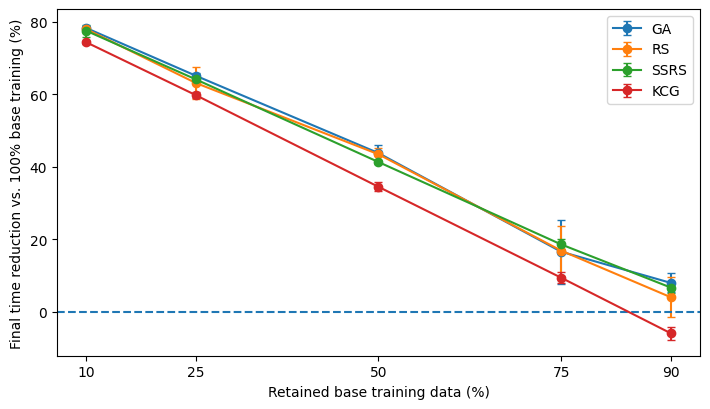

Saved: c:\Users\Juan Manuel\Desktop\tfm\analysis_outputs\figures\tiny_imagenet_time_reduction_all_methods.pdf
Saved: c:\Users\Juan Manuel\Desktop\tfm\analysis_outputs\figures\tiny_imagenet_time_reduction_all_methods.png


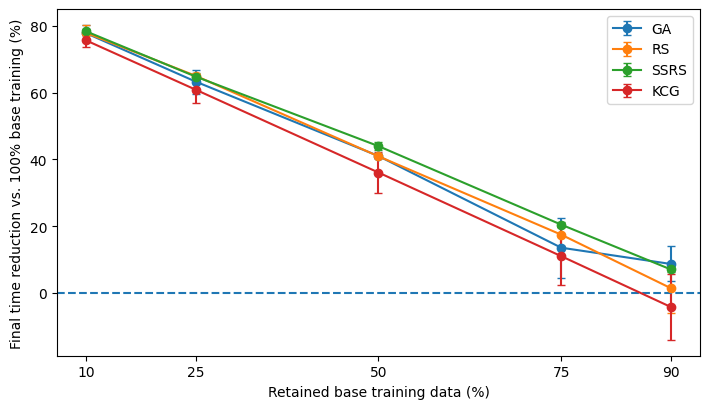

In [10]:
# Paired comparison with the 100% base training baseline

baseline_by_seed = full_test_df[
    [
        "dataset",
        "search_seed",
        "accuracy",
        "test_duration_seconds",
    ]
].rename(
    columns={
        "accuracy": "baseline_accuracy",
        "test_duration_seconds": "baseline_duration",
    }
)

paired_vs_full = selected_test_df.merge(
    baseline_by_seed,
    on=["dataset", "search_seed"],
    how="inner",
    validate="many_to_one",
)

paired_vs_full["accuracy_difference_pp"] = (
    paired_vs_full["accuracy"]
    - paired_vs_full["baseline_accuracy"]
) * 100

paired_vs_full["time_reduction_percent"] = (
    1
    - paired_vs_full["test_duration_seconds"]
    / paired_vs_full["baseline_duration"]
) * 100

efficiency_table = (
    paired_vs_full
    .groupby(["dataset_name", "retention", "method"])
    .agg(
        accuracy_difference_mean_pp=(
            "accuracy_difference_pp",
            "mean",
        ),
        accuracy_difference_std_pp=(
            "accuracy_difference_pp",
            "std",
        ),
        final_time_mean_seconds=(
            "test_duration_seconds",
            "mean",
        ),
        time_reduction_mean_percent=(
            "time_reduction_percent",
            "mean",
        ),
        time_reduction_std_percent=(
            "time_reduction_percent",
            "std",
        ),
    )
    .reset_index()
    .sort_values(["dataset_name", "retention", "method"])
)

display(efficiency_table.round(3))

efficiency_table.to_csv(
    TABLES_DIR / "main_efficiency_vs_base_training.csv",
    index=False,
)


# Figure: final retraining-and-evaluation time reduction

for dataset_name in DATASET_NAMES.values():
    dataset_efficiency = efficiency_table[
        efficiency_table["dataset_name"] == dataset_name
    ]

    plt.figure(figsize=(7.2, 4.2))

    for method in ["GA", "RS", "SSRS", "KCG"]:
        method_data = dataset_efficiency[
            dataset_efficiency["method"] == method
        ].sort_values("retention")

        plt.errorbar(
            method_data["retention"],
            method_data["time_reduction_mean_percent"],
            yerr=method_data["time_reduction_std_percent"],
            marker="o",
            capsize=3,
            label=method,
        )

    plt.axhline(0, linestyle="--")
    plt.xlabel("Retained base training data (%)")
    plt.ylabel("Final time reduction vs. 100% base training (%)")
    plt.xticks(RETENTIONS)
    plt.legend()
    plt.tight_layout()

    filename = (
        dataset_name.lower()
        .replace("-", "")
        .replace(" ", "_")
    )

    save_figure(f"{filename}_time_reduction_all_methods")
    plt.show()

In [11]:
# Descriptive ranks, wins and seed-level statistical diagnostics

ranked_main = selected_test_df.copy()

ranked_main["block_rank"] = (
    ranked_main
    .groupby(
        ["dataset", "retention", "search_seed"]
    )["accuracy"]
    .rank(ascending=False, method="average")
)

block_rank_summary = (
    ranked_main
    .groupby(["dataset_name", "method"])
    .agg(
        mean_block_rank=("block_rank", "mean"),
        block_wins=(
            "block_rank",
            lambda values: int((values == 1).sum()),
        ),
    )
    .reset_index()
)

display(block_rank_summary.round(3))

block_rank_summary.to_csv(
    TABLES_DIR / "main_block_rank_summary.csv",
    index=False,
)


# Aggregate the five retention levels within each independent search seed.
seed_level_main = (
    selected_test_df
    .groupby(["dataset", "search_seed", "method"])
    .agg(seed_mean_accuracy=("accuracy", "mean"))
    .reset_index()
)

main_statistical_records = []
main_pairwise_records = []

for dataset_code, dataset_name in DATASET_NAMES.items():
    seed_pivot = (
        seed_level_main[
            seed_level_main["dataset"] == dataset_code
        ]
        .pivot(
            index="search_seed",
            columns="method",
            values="seed_mean_accuracy",
        )
        [["GA", "RS", "SSRS", "KCG"]]
    )

    friedman = stats.friedmanchisquare(
        *[seed_pivot[column] for column in seed_pivot.columns]
    )

    main_statistical_records.append(
        {
            "dataset": dataset_name,
            "friedman_statistic": friedman.statistic,
            "friedman_p_value": friedman.pvalue,
        }
    )

    methods = list(seed_pivot.columns)

    for i, method_a in enumerate(methods):
        for method_b in methods[i + 1:]:
            result = exact_wilcoxon(
                seed_pivot[method_a],
                seed_pivot[method_b],
            )

            differences_pp = (
                seed_pivot[method_a]
                - seed_pivot[method_b]
            ) * 100

            # Win/tie/loss counts are reported over the 25 retention-seed
            # blocks as descriptive information.
            block_pivot = (
                selected_test_df[
                    selected_test_df["dataset"] == dataset_code
                ]
                .pivot(
                    index=["retention", "search_seed"],
                    columns="method",
                    values="accuracy",
                )
            )

            block_differences = (
                block_pivot[method_a]
                - block_pivot[method_b]
            ) * 100

            main_pairwise_records.append(
                {
                    "dataset": dataset_name,
                    "method_a": method_a,
                    "method_b": method_b,
                    "seed_level_mean_difference_pp": (
                        differences_pp.mean()
                    ),
                    "block_mean_difference_pp": (
                        block_differences.mean()
                    ),
                    "method_a_block_wins": int(
                        (block_differences > 0).sum()
                    ),
                    "ties": int(
                        (block_differences == 0).sum()
                    ),
                    "method_b_block_wins": int(
                        (block_differences < 0).sum()
                    ),
                    "wilcoxon_statistic": result.statistic,
                    "raw_p_value": result.pvalue,
                }
            )

main_statistics = pd.DataFrame(main_statistical_records)
main_pairwise = pd.DataFrame(main_pairwise_records)

# Apply Holm correction separately within each dataset over all six pairwise tests.
main_pairwise["holm_p_value"] = np.nan

for dataset_name in DATASET_NAMES.values():
    mask = main_pairwise["dataset"] == dataset_name

    main_pairwise.loc[mask, "holm_p_value"] = holm_adjust(
        main_pairwise.loc[mask, "raw_p_value"]
    )

print("Dataset-level Friedman diagnostics")
display(main_statistics.round(6))

print("Pairwise seed-level Wilcoxon diagnostics")
display(
    main_pairwise
    .sort_values(["dataset", "holm_p_value"])
    .round(6)
)

main_statistics.to_csv(
    TABLES_DIR / "main_friedman_statistics.csv",
    index=False,
)
main_pairwise.to_csv(
    TABLES_DIR / "main_pairwise_statistics.csv",
    index=False,
)

print(
    "Reminder: with only five paired seeds, the minimum exact two-sided "
    "Wilcoxon p-value is 0.0625. Pairwise inference is therefore severely "
    "resolution-limited."
)

,dataset_name,method,mean_block_rank,block_wins
0,CIFAR-10,GA,1.80,11
1,CIFAR-10,KCG,2.84,4
2,CIFAR-10,RS,2.52,8
3,CIFAR-10,SSRS,2.84,2
4,Tiny ImageNet,GA,2.52,4
5,Tiny ImageNet,KCG,2.64,8
6,Tiny ImageNet,RS,2.40,7
7,Tiny ImageNet,SSRS,2.44,6


Dataset-level Friedman diagnostics


,dataset,friedman_statistic,friedman_p_value
0,CIFAR-10,9.00,0.029291
1,Tiny ImageNet,9.72,0.021103


Pairwise seed-level Wilcoxon diagnostics


,dataset,method_a,method_b,seed_level_mean_difference_pp,block_mean_difference_pp,method_a_block_wins,ties,method_b_block_wins,wilcoxon_statistic,raw_p_value,holm_p_value
1,CIFAR-10,GA,SSRS,0.3376,0.3376,19,0,6,0.0,0.0625,0.375
2,CIFAR-10,GA,KCG,0.3820,0.3820,20,0,5,0.0,0.0625,0.375
0,CIFAR-10,GA,RS,0.1884,0.1884,16,0,9,4.0,0.4375,1.000
3,CIFAR-10,RS,SSRS,0.1492,0.1492,14,0,11,6.0,0.8125,1.000
4,CIFAR-10,RS,KCG,0.1936,0.1936,14,0,11,3.0,0.3125,1.000
5,CIFAR-10,SSRS,KCG,0.0444,0.0444,12,0,13,4.0,0.4375,1.000
8,Tiny ImageNet,GA,KCG,-0.3588,-0.3588,13,0,12,0.0,0.0625,0.375
10,Tiny ImageNet,RS,KCG,-0.5096,-0.5096,13,0,12,0.0,0.0625,0.375
11,Tiny ImageNet,SSRS,KCG,-0.4420,-0.4420,15,0,10,0.0,0.0625,0.375
6,Tiny ImageNet,GA,RS,0.1508,0.1508,12,0,13,4.0,0.4375,1.000


Reminder: with only five paired seeds, the minimum exact two-sided Wilcoxon p-value is 0.0625. Pairwise inference is therefore severely resolution-limited.


## 3. Selection cost

Selection time is reported by method because the measured operations differ: GA/RS perform wrapper search guided by validation performance, SSRS constructs one stratified mask, and KCG uses reusable geometric preprocessing plus farthest-first traversal.


In [12]:
# GA/RS search cost

main_search_df["method"] = main_search_df["algorithm"].map(
    MAIN_METHOD_NAMES
)
main_search_df["retention"] = (
    main_search_df["keep_percentage"] * 100
).round().astype(int)
main_search_df["dataset_name"] = main_search_df["dataset"].map(
    DATASET_NAMES
)

guided_search_cost = (
    main_search_df
    .groupby(["dataset_name", "method", "retention"])
    .agg(
        search_minutes_mean=(
            "search_duration_seconds",
            lambda values: values.mean() / 60,
        ),
        search_minutes_std=(
            "search_duration_seconds",
            lambda values: values.std() / 60,
        ),
    )
    .reset_index()
)

print("GA/RS B=1000 search time")
display(guided_search_cost.round(2))


# SSRS selection cost

srs_search_df["retention"] = (
    srs_search_df["keep_percentage"] * 100
).round().astype(int)
srs_search_df["dataset_name"] = srs_search_df["dataset"].map(
    DATASET_NAMES
)

srs_selection_cost = (
    srs_search_df
    .groupby(["dataset_name", "retention"])
    .agg(
        selection_seconds_mean=("search_duration_seconds", "mean"),
        selection_seconds_std=("search_duration_seconds", "std"),
    )
    .reset_index()
)

print("SSRS mask-construction time")
display(srs_selection_cost.round(4))


# KCG recorded selection cost

kcg_search_df["retention"] = (
    kcg_search_df["keep_percentage"] * 100
).round().astype(int)
kcg_search_df["dataset_name"] = kcg_search_df["dataset"].map(
    DATASET_NAMES
)

kcg_selection_cost = (
    kcg_search_df
    .groupby(["dataset_name", "retention"])
    .agg(
        selection_seconds_mean=("search_duration_seconds", "mean"),
        selection_seconds_std=("search_duration_seconds", "std"),
    )
    .reset_index()
)

print(
    "KCG recorded selection time. The first 10% record of seed 42 "
    "contains the one-time shared cache build and first farthest-first order."
)
display(kcg_selection_cost.round(3))


# Parse KCG shared-cache timing from logs

cache_records = []
order_records = []

cache_pattern = re.compile(
    r"Global pairwise distance cache completed \| seconds=([0-9.]+)"
)
order_pattern = re.compile(
    r"Global farthest-first order completed \| seed=(\d+) "
    r"\| centers=\d+ \| seconds=([0-9.]+)"
)

for dataset_code, dataset_name in DATASET_NAMES.items():
    experiment_dir = (
        RESULTS_DIR
        / "main"
        / "kcg"
        / f"main_global_kcg_{dataset_code.lower()}_alexnet_all"
    )
    log_path = experiment_dir / "logs" / "run.log"

    if not log_path.exists():
        continue

    log_text = log_path.read_text(encoding="utf-8")

    cache_match = cache_pattern.search(log_text)

    if cache_match:
        cache_records.append(
            {
                "dataset": dataset_name,
                "shared_pairwise_cache_seconds": float(
                    cache_match.group(1)
                ),
            }
        )

    for seed, seconds in order_pattern.findall(log_text):
        order_records.append(
            {
                "dataset": dataset_name,
                "search_seed": int(seed),
                "farthest_first_order_seconds": float(seconds),
            }
        )

kcg_cache_cost = pd.DataFrame(cache_records)
kcg_order_cost = pd.DataFrame(order_records)

print("One-time KCG pairwise-distance cache")
display(kcg_cache_cost.round(3))

print("KCG farthest-first order by seed")
display(kcg_order_cost.round(3))

guided_search_cost.to_csv(
    TABLES_DIR / "guided_search_cost_b1000.csv",
    index=False,
)
srs_selection_cost.to_csv(
    TABLES_DIR / "ssrs_selection_cost.csv",
    index=False,
)
kcg_selection_cost.to_csv(
    TABLES_DIR / "kcg_recorded_selection_cost.csv",
    index=False,
)
kcg_cache_cost.to_csv(
    TABLES_DIR / "kcg_shared_cache_cost.csv",
    index=False,
)
kcg_order_cost.to_csv(
    TABLES_DIR / "kcg_farthest_first_order_cost.csv",
    index=False,
)

GA/RS B=1000 search time


,dataset_name,method,retention,search_minutes_mean,search_minutes_std
0,CIFAR-10,GA,10,98.79,6.51
1,CIFAR-10,GA,25,173.60,7.45
2,CIFAR-10,GA,50,288.38,9.02
3,CIFAR-10,GA,75,371.25,23.56
4,CIFAR-10,GA,90,409.34,4.90
5,CIFAR-10,RS,10,101.61,7.84
6,CIFAR-10,RS,25,159.63,8.78
7,CIFAR-10,RS,50,303.28,9.76
8,CIFAR-10,RS,75,396.30,24.07
9,CIFAR-10,RS,90,448.17,17.91


SSRS mask-construction time


,dataset_name,retention,selection_seconds_mean,selection_seconds_std
0,CIFAR-10,10,0.0192,0.0023
1,CIFAR-10,25,0.0263,0.0079
2,CIFAR-10,50,0.0281,0.0042
3,CIFAR-10,75,0.0323,0.0057
4,CIFAR-10,90,0.0338,0.0034
5,Tiny ImageNet,10,0.0375,0.0053
6,Tiny ImageNet,25,0.0427,0.0068
7,Tiny ImageNet,50,0.0530,0.0097
8,Tiny ImageNet,75,0.0509,0.0042
9,Tiny ImageNet,90,0.0576,0.0077


KCG recorded selection time. The first 10% record of seed 42 contains the one-time shared cache build and first farthest-first order.


,dataset_name,retention,selection_seconds_mean,selection_seconds_std
0,CIFAR-10,10,81.877,174.405
1,CIFAR-10,25,1.408,0.021
2,CIFAR-10,50,1.389,0.079
3,CIFAR-10,75,1.378,0.067
4,CIFAR-10,90,1.404,0.053
5,Tiny ImageNet,10,310.276,667.373
6,Tiny ImageNet,25,2.683,0.055
7,Tiny ImageNet,50,2.684,0.024
8,Tiny ImageNet,75,2.701,0.086
9,Tiny ImageNet,90,2.737,0.135


One-time KCG pairwise-distance cache


,dataset,shared_pairwise_cache_seconds
0,CIFAR-10,295.494
1,Tiny ImageNet,1156.833


KCG farthest-first order by seed


,dataset,search_seed,farthest_first_order_seconds
0,CIFAR-10,42,94.189
1,CIFAR-10,123,2.156
2,CIFAR-10,456,2.214
3,CIFAR-10,789,2.098
4,CIFAR-10,1024,2.080
5,Tiny ImageNet,42,337.917
6,Tiny ImageNet,123,9.282
7,Tiny ImageNet,456,8.444
8,Tiny ImageNet,789,7.519
9,Tiny ImageNet,1024,7.746


## 4. GA/RS convergence at B=1000

The saved best-fitness histories are used to determine when each run first reached its final best validation fitness and to plot representative best-so-far curves at 50% retention.


In [13]:
# Load B=1000 best-fitness histories

history_records = []
best_found_records = []

for experiment_dir in sorted(RESULTS_DIR.glob("main/guided_b1000/main_b1000_*")):
    for history_path in experiment_dir.rglob(
        "best_fitness_history.json"
    ):
        with history_path.open("r", encoding="utf-8") as file:
            history_object = json.load(file)

        history = history_object["best_fitness_history"]

        configuration_path = history_path.parent / "configuration.json"
        search_summary_path = history_path.parent / "search_summary.json"

        with configuration_path.open("r", encoding="utf-8") as file:
            configuration = json.load(file)

        with search_summary_path.open("r", encoding="utf-8") as file:
            search_summary = json.load(file)

        dataset = configuration["dataset"]
        algorithm = configuration["algorithm"]
        retention = int(
            round(configuration["keep_percentage"] * 100)
        )
        seed = int(configuration["search_seed"])

        if (
            dataset not in DATASET_NAMES
            or algorithm not in {"GEN", "RS"}
            or search_summary["max_evaluations"] != 1000
        ):
            continue

        if len(history) != 1000:
            raise AssertionError(
                f"Expected 1000 history values in {history_path}, "
                f"found {len(history)}."
            )

        history_array = np.asarray(history, dtype=float)
        final_best = history_array[-1]

        # The first occurrence is the evaluation where the final best
        # fitness was initially discovered.
        best_found_evaluation = int(
            np.argmax(history_array == final_best) + 1
        )

        best_found_records.append(
            {
                "dataset": dataset,
                "dataset_name": DATASET_NAMES[dataset],
                "algorithm": algorithm,
                "method": MAIN_METHOD_NAMES[algorithm],
                "retention": retention,
                "search_seed": seed,
                "final_best_fitness": final_best,
                "best_found_evaluation": best_found_evaluation,
            }
        )

        for evaluation, best_fitness in enumerate(
            history_array,
            start=1,
        ):
            history_records.append(
                {
                    "dataset": dataset,
                    "dataset_name": DATASET_NAMES[dataset],
                    "method": MAIN_METHOD_NAMES[algorithm],
                    "retention": retention,
                    "search_seed": seed,
                    "evaluation": evaluation,
                    "best_fitness": best_fitness,
                }
            )

best_found_df = pd.DataFrame(best_found_records)
history_df = pd.DataFrame(history_records)

assert len(best_found_df) == 100

best_found_summary = (
    best_found_df
    .groupby(["dataset_name", "method", "retention"])
    .agg(
        mean_best_found_evaluation=(
            "best_found_evaluation",
            "mean",
        ),
        median_best_found_evaluation=(
            "best_found_evaluation",
            "median",
        ),
        max_best_found_evaluation=(
            "best_found_evaluation",
            "max",
        ),
    )
    .reset_index()
)

display(best_found_summary.round(1))

threshold_records = []

for threshold in [100, 250, 500, 750, 1000]:
    threshold_records.append(
        {
            "evaluation_threshold": threshold,
            "fraction_of_runs_final_best_already_found": (
                best_found_df["best_found_evaluation"] <= threshold
            ).mean(),
        }
    )

threshold_summary = pd.DataFrame(threshold_records)
threshold_summary[
    "percentage_of_runs_final_best_already_found"
] = (
    threshold_summary[
        "fraction_of_runs_final_best_already_found"
    ] * 100
)

display(threshold_summary.round(2))

best_found_summary.to_csv(
    TABLES_DIR / "b1000_best_found_evaluation.csv",
    index=False,
)
threshold_summary.to_csv(
    TABLES_DIR / "b1000_best_found_thresholds.csv",
    index=False,
)

,dataset_name,method,retention,mean_best_found_evaluation,median_best_found_evaluation,max_best_found_evaluation
0,CIFAR-10,GA,10,346.2,241.0,633
1,CIFAR-10,GA,25,281.2,169.0,575
2,CIFAR-10,GA,50,335.0,446.0,716
3,CIFAR-10,GA,75,543.0,648.0,998
4,CIFAR-10,GA,90,494.4,645.0,790
5,CIFAR-10,RS,10,655.8,722.0,788
6,CIFAR-10,RS,25,322.8,192.0,673
7,CIFAR-10,RS,50,251.0,241.0,465
8,CIFAR-10,RS,75,596.4,727.0,752
9,CIFAR-10,RS,90,296.8,245.0,670


,evaluation_threshold,fraction_of_runs_final_best_already_found,percentage_of_runs_final_best_already_found
0,100,0.10,10.0
1,250,0.35,35.0
2,500,0.54,54.0
3,750,0.90,90.0
4,1000,1.00,100.0


Saved: c:\Users\Juan Manuel\Desktop\tfm\analysis_outputs\figures\cifar10_convergence_kp50.pdf
Saved: c:\Users\Juan Manuel\Desktop\tfm\analysis_outputs\figures\cifar10_convergence_kp50.png


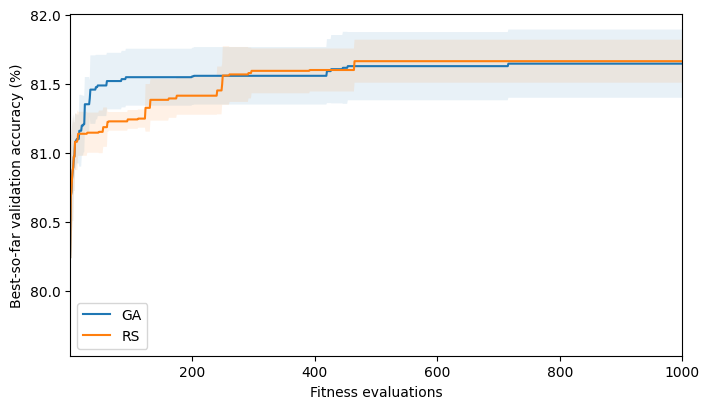

Saved: c:\Users\Juan Manuel\Desktop\tfm\analysis_outputs\figures\tiny_imagenet_convergence_kp50.pdf
Saved: c:\Users\Juan Manuel\Desktop\tfm\analysis_outputs\figures\tiny_imagenet_convergence_kp50.png


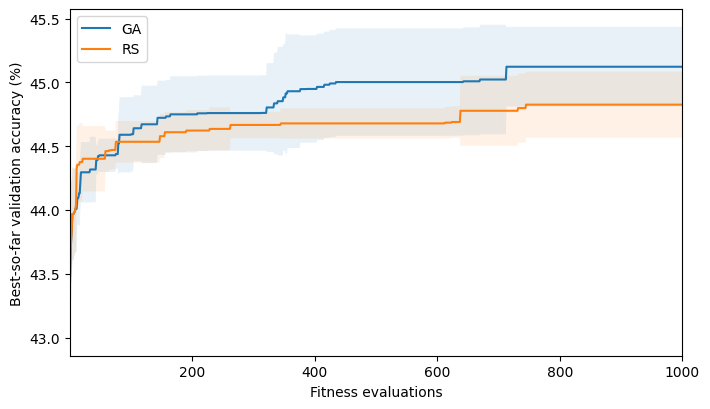

In [14]:
# Representative convergence curves at 50% retention

CONVERGENCE_RETENTION = 50

convergence_summary = (
    history_df[
        history_df["retention"] == CONVERGENCE_RETENTION
    ]
    .groupby(
        ["dataset_name", "method", "evaluation"]
    )
    .agg(
        best_fitness_mean=("best_fitness", "mean"),
        best_fitness_std=("best_fitness", "std"),
    )
    .reset_index()
)

for dataset_name in DATASET_NAMES.values():
    dataset_convergence = convergence_summary[
        convergence_summary["dataset_name"] == dataset_name
    ]

    plt.figure(figsize=(7.2, 4.2))

    for method in ["GA", "RS"]:
        method_data = dataset_convergence[
            dataset_convergence["method"] == method
        ].sort_values("evaluation")

        plt.plot(
            method_data["evaluation"],
            method_data["best_fitness_mean"] * 100,
            label=method,
        )

        plt.fill_between(
            method_data["evaluation"],
            (
                method_data["best_fitness_mean"]
                - method_data["best_fitness_std"]
            ) * 100,
            (
                method_data["best_fitness_mean"]
                + method_data["best_fitness_std"]
            ) * 100,
            alpha=0.10,
        )

    plt.xlabel("Fitness evaluations")
    plt.ylabel("Best-so-far validation accuracy (%)")
    plt.xlim(1, 1000)
    plt.legend()
    plt.tight_layout()

    filename = (
        dataset_name.lower()
        .replace("-", "")
        .replace(" ", "_")
    )

    save_figure(
        f"{filename}_convergence_kp{CONVERGENCE_RETENTION}"
    )
    plt.show()

## 5. Budget diagnostic: B=100 vs B=1000

The earlier CIFAR-10 and Tiny ImageNet `B=100` runs are retained only as a diagnostic comparison. The thesis uses the `B=1000` runs as the definitive GA/RS main-stage results.


In [15]:
# Optional B=100 vs B=1000 diagnostic

old_main_search_frames = []
old_main_test_frames = []

for dataset_prefix in [
    "diagnostics/guided_b100/prelim_features_cifar10_alexnet_*",
    "diagnostics/guided_b100/prelim_features_tinyimagenet_alexnet_*",
]:
    old_main_search_frames.append(
        load_top_level_csvs(
            dataset_prefix,
            "search_summary.csv",
        )
    )
    old_main_test_frames.append(
        load_top_level_csvs(
            dataset_prefix,
            "test_summary.csv",
        )
    )

old_main_search_df = pd.concat(
    old_main_search_frames,
    ignore_index=True,
)
old_main_test_df = pd.concat(
    old_main_test_frames,
    ignore_index=True,
)

old_main_search_df = old_main_search_df[
    (old_main_search_df["status"] == "completed")
    & (old_main_search_df["algorithm"].isin(["GEN", "RS"]))
    & (old_main_search_df["max_evaluations"] == 100)
].copy()

old_main_test_df = old_main_test_df[
    (old_main_test_df["status"] == "completed")
    & (old_main_test_df["record_type"] == "selected_mask")
    & (old_main_test_df["algorithm"].isin(["GEN", "RS"]))
].copy()

old_main_search_df["retention"] = (
    old_main_search_df["keep_percentage"] * 100
).round().astype(int)
old_main_test_df["retention"] = (
    old_main_test_df["keep_percentage"] * 100
).round().astype(int)

old_main_search_df["method"] = old_main_search_df["algorithm"].map(
    MAIN_METHOD_NAMES
)
old_main_test_df["method"] = old_main_test_df["algorithm"].map(
    MAIN_METHOD_NAMES
)

new_search_for_budget = main_search_df.copy()
new_test_for_budget = main_test_df.copy()

new_search_for_budget["retention"] = (
    new_search_for_budget["keep_percentage"] * 100
).round().astype(int)
new_test_for_budget["retention"] = (
    new_test_for_budget["keep_percentage"] * 100
).round().astype(int)

new_search_for_budget["method"] = (
    new_search_for_budget["algorithm"].map(MAIN_METHOD_NAMES)
)
new_test_for_budget["method"] = (
    new_test_for_budget["algorithm"].map(MAIN_METHOD_NAMES)
)

budget_validation = (
    old_main_search_df
    .groupby(["dataset", "method", "retention"])
    .agg(B100_validation=("best_fitness", "mean"))
    .join(
        new_search_for_budget
        .groupby(["dataset", "method", "retention"])
        .agg(B1000_validation=("best_fitness", "mean"))
    )
    .reset_index()
)

budget_validation["validation_gain_pp"] = (
    budget_validation["B1000_validation"]
    - budget_validation["B100_validation"]
) * 100

budget_test = (
    old_main_test_df
    .groupby(["dataset", "method", "retention"])
    .agg(B100_test=("accuracy", "mean"))
    .join(
        new_test_for_budget
        .groupby(["dataset", "method", "retention"])
        .agg(B1000_test=("accuracy", "mean"))
    )
    .reset_index()
)

budget_test["test_gain_pp"] = (
    budget_test["B1000_test"]
    - budget_test["B100_test"]
) * 100

budget_comparison = budget_validation.merge(
    budget_test,
    on=["dataset", "method", "retention"],
    how="inner",
)

budget_comparison["dataset"] = budget_comparison["dataset"].map(
    DATASET_NAMES
)

display(budget_comparison.round(4))

budget_comparison.to_csv(
    TABLES_DIR / "optional_budget_100_vs_1000.csv",
    index=False,
)

,dataset,method,retention,B100_validation,B1000_validation,validation_gain_pp,B100_test,B1000_test,test_gain_pp
0,CIFAR-10,GA,10,0.7847,0.7866,0.182,0.7761,0.7748,-0.130
1,CIFAR-10,GA,25,0.8045,0.8056,0.114,0.7894,0.7918,0.240
2,CIFAR-10,GA,50,0.8155,0.8164,0.098,0.7982,0.7997,0.154
3,CIFAR-10,GA,75,0.8196,0.8232,0.368,0.8030,0.8016,-0.138
4,CIFAR-10,GA,90,0.8223,0.8244,0.210,0.8052,0.8087,0.350
5,CIFAR-10,RS,10,0.7819,0.7843,0.238,0.7730,0.7697,-0.330
6,CIFAR-10,RS,25,0.8022,0.8042,0.192,0.7853,0.7892,0.394
7,CIFAR-10,RS,50,0.8124,0.8166,0.422,0.8003,0.8021,0.184
8,CIFAR-10,RS,75,0.8193,0.8210,0.172,0.8051,0.7992,-0.582
9,CIFAR-10,RS,90,0.8222,0.8232,0.096,0.8079,0.8069,-0.102


## 6. Generated artifacts

Running the notebook writes publication-ready figures to `analysis_outputs/figures/` and numeric tables to `analysis_outputs/tables/`.
